In [7]:
# !pip install onnx==1.16.0 onnxruntime==1.16.3 onnxscript

In [1]:
# for gpu
# !pip install onnx==1.16.0 onnxruntime-gpu==1.17.1 onnxscript
# !apt-get install libcudnn8 libcudnn8-dev

In [3]:
# !pip install efficientnet_pytorch
# !pip install numpy==1.26.4

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import sys
from pathlib import Path
import onnxruntime as ort
import numpy as np

src_path = "../"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

In [2]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [3]:
from model_plagiarism_torch import ImageEncoder, ImageFuser, BinaryMatchHead, TransformationDecoder
from src.dataset import ImageTransformer, TransformTokenizer

#### ImageEncoder

In [4]:
encoder = ImageEncoder()
encoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.pth'))
encoder.eval()
print('ready')

ready


In [5]:
# dummy_input = torch.randn(1, 3, 300, 300, device='cpu')

# torch.onnx.export(
#     encoder,
#     dummy_input,
#     '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.onnx',
#     input_names=["image_input"],
#     output_names=["image_embedding"],
#     opset_version=18,
#     do_constant_folding=True,
#     dynamic_axes={
#         "image_input": {
#             0: "batch_size"
#         },
#         "image_embedding": {
#             0: "batch_size",
#         }
#     },
#     verbose=False
# )

#### how to use onnx

In [14]:
ort.get_available_providers()

['AzureExecutionProvider', 'CPUExecutionProvider']

In [15]:
ort.__version__

'1.16.3'

In [17]:
# 1. Указываем провайдеры: сначала GPU (CUDA), потом CPU
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

# 2. Передаем providers в сессию
ort_session = ort.InferenceSession(
    '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.onnx',
    providers=providers
)

# Проверка: какие провайдеры активны
print("Активные провайдеры:", ort_session.get_providers())

Активные провайдеры: ['CPUExecutionProvider']


In [18]:
ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/image_encoder.onnx')

inputs = ort_session.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = ort_session.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: image_input, shape: ['batch_size', 3, 300, 300], type: tensor(float)
Output name: image_embedding, shape: ['batch_size', 1536], type: tensor(float)


In [19]:
dummy_input = torch.randn(1, 3, 300, 300, device='cpu')

In [20]:
import numpy as np
outputs = ort_session.run(None, {'image_input': np.array(dummy_input)})

In [21]:
outputs[0].shape

(1, 1536)

In [22]:
dummy_input = torch.randn(1, 3, 300, 300, device='cpu')

In [24]:
# !python -m pip install --force-reinstall -U ap_res_models_inference --index-url https://nexus.ap-team.ru/repository/pypi/simple

# from ap_res_models_inference import get_model
# import numpy as np

# model = get_model(
#     engine_name= 'onnx',
#     path_to_weights='/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/image_encoder.onnx',
#     use_gpu=0
# )

# outputs = model(image_input=np.array(dummy_input)) # image_input namespace from export
# outputs.shape

#### ImageFuser

In [6]:
fuser = ImageFuser()
fuser.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/fuser.pth'))
fuser.eval()
print('ready')

ready


In [32]:
# dummy_source = torch.randn(1, 1536, device='cpu')
# dummy_query = torch.randn(1, 1536, device='cpu')

# torch.onnx.export(
#         fuser,
#         (dummy_source, dummy_query),
#         '/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/fuser.onnx',
#         input_names=["source_embedding", "query_embedding"],
#         output_names=["fused_context"],
#         opset_version=18,
#         do_constant_folding=True,
#         dynamic_axes={
#             "source_embedding": {0: "batch_size"},
#             "query_embedding": {0: "batch_size"},
#             "fused_context":   {0: "batch_size", 1: "seq_len"}
#         },
#         verbose=False
#     )

In [7]:
ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/fuser.onnx')

inputs = ort_session.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = ort_session.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: source_embedding, shape: ['batch_size', 1536], type: tensor(float)
Input name: query_embedding, shape: ['batch_size', 1536], type: tensor(float)
Output name: fused_context, shape: ['batch_size', 4, 512], type: tensor(float)


In [9]:
source_embedding = torch.randn(2, 1536, device='cpu')
query_embedding = torch.randn(2, 1536, device='cpu')

outputs = ort_session.run(None, {'source_embedding': np.array(source_embedding), 'query_embedding': np.array(query_embedding)})
outputs[0].shape

(2, 4, 512)

#### decoder

In [10]:
decoder = TransformationDecoder()
decoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder.pth'))
decoder.eval()
print('ready')

ready


In [9]:
# dummy_context = torch.randn(
#     1,
#     4,
#     512,
#     device='cpu',
#     dtype=torch.float32,
#     requires_grad=False
# )


# dummy_tokens = torch.full(
#     (1, 1),
#     fill_value=1,  # bos_token_id
#     device='cpu',
#     dtype=torch.long
# )

# torch.onnx.export(
#     decoder,
#     (dummy_context, dummy_tokens),  # context: [B, L, D], tokens: [B, T]
#     "/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder_step.onnx",
#     input_names=["context_embeddings", "token_ids"],
#     output_names=["next_logits"],
#     opset_version=18,
#     do_constant_folding=True,
#     dynamic_axes={
#         "context_embeddings": {0: "batch_size", 1: "context_len"},
#         "token_ids": {0: "batch_size", 1: "seq_len"},
#         "next_logits": {0: "batch_size"}
#     },
#     verbose=False
# )

In [11]:
ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder_step.onnx')

inputs = ort_session.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = ort_session.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: context_embeddings, shape: ['batch_size', 'context_len', 512], type: tensor(float)
Input name: token_ids, shape: ['batch_size', 'seq_len'], type: tensor(int64)
Output name: next_logits, shape: ['batch_size', 13], type: tensor(float)


In [21]:
ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/decoder_step.onnx')
# ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_dev_v1/decoder_step.onnx')

dummy_context = torch.randn(2, 4, 512)
dummy_tokens = torch.tensor([[1, 2, 4]], dtype=torch.long)
dummy_tokens = dummy_tokens.repeat(2, 1) 

outputs = ort_session.run(None, {'context_embeddings': np.array(dummy_context), 'token_ids': np.array(dummy_tokens)})
outputs[0].shape

(2, 13)

#### match_head

In [23]:
match_head = BinaryMatchHead()
match_head.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/match_head.pth'))
match_head.eval()
print('ready')

ready


In [39]:
# dummy_context = torch.randn(
#     1,
#     4,
#     512,
#     device='cpu',
#     dtype=torch.float32,
#     requires_grad=False
# )

# torch.onnx.export(
#     match_head,
#     dummy_context,  # context: [B, L, D]
#     "/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/match_head.onnx",
#     input_names=["context_embeddings"],
#     output_names=["match_prob"],
#     opset_version=17,
#     do_constant_folding=True,
#     dynamic_axes={
#         "context_embeddings": {0: "batch_size", 1: "context_len"},
#         "match_prob": {0: "batch_size"}
#     },
#     verbose=False
# )

In [24]:
ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/match_head.onnx')

dummy_context = torch.randn(2, 4, 512)

outputs = ort_session.run(None, {'context_embeddings': np.array(dummy_context)})
outputs[0].shape

(2,)

In [25]:
outputs

[array([0.38087615, 0.7082918 ], dtype=float32)]

#### Tests

['horizontal_flip', 'grayscale', 'rotate_90']


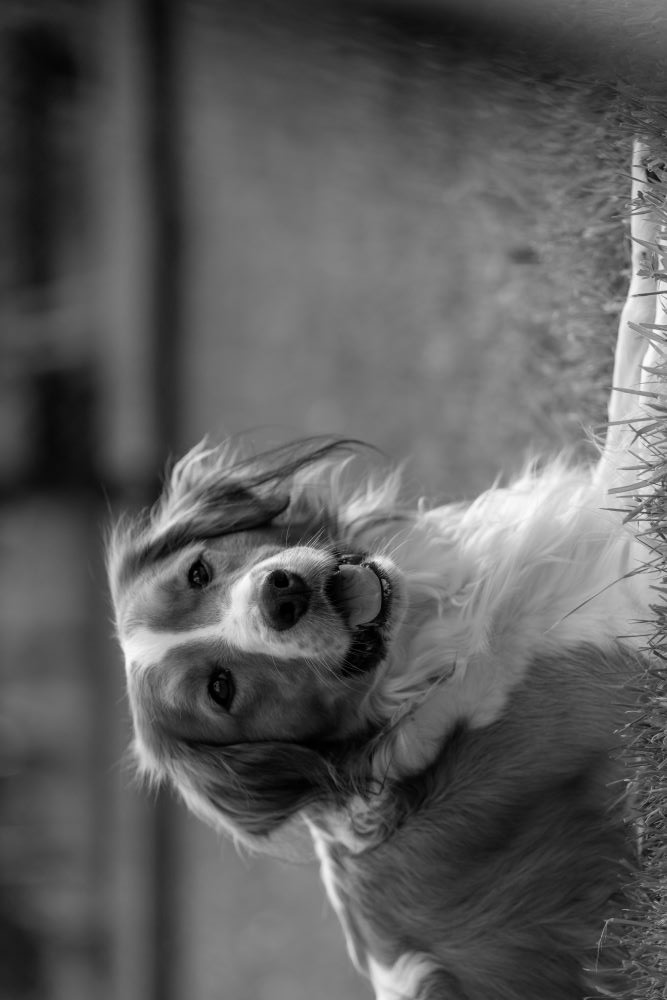

In [26]:
image_path = '../assets/image.jpg'
image = Image.open(image_path)

it = ImageTransformer()
tokenizer = TransformTokenizer()

transformed_image, sequence = it.transform(image, p=0.3)
print(sequence)
transformed_image

In [27]:
image_tensor = preprocess(image).unsqueeze(0).repeat(3, 1, 1, 1)
transformed_image_tensor = preprocess(transformed_image).unsqueeze(0).repeat(3, 1, 1, 1)

In [28]:
image_embs, transformed_image_embs = encoder(image_tensor), encoder(transformed_image_tensor)

In [29]:
image_embs.shape

torch.Size([3, 1536])

In [30]:
images_embeddings = fuser(image_embs, transformed_image_embs)

In [31]:
torch.tensor([[1, 2]])

tensor([[1, 2]])

In [32]:
decoder(images_embeddings, idx=torch.tensor([[1, 2]]).repeat(3, 1))

tensor([[-20.4310, -20.4113,  -7.5021, -13.6334,   3.5302,   3.0070,  -5.2096,
           3.1517,  -2.1411,  -2.0714,  -3.9184,   2.8345,   2.7133],
        [-20.4310, -20.4113,  -7.5021, -13.6334,   3.5302,   3.0070,  -5.2096,
           3.1517,  -2.1411,  -2.0714,  -3.9184,   2.8345,   2.7133],
        [-20.4310, -20.4113,  -7.5021, -13.6334,   3.5302,   3.0070,  -5.2096,
           3.1517,  -2.1411,  -2.0714,  -3.9184,   2.8345,   2.7133]],
       grad_fn=<SliceBackward0>)

In [33]:
generated = decoder.generate(images_embeddings, max_new_tokens=10, do_sample=False) #, top_k=3)

tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence}")

Predicted: ['grayscale', 'rotate_270', 'horizontal_flip']
Target: ['horizontal_flip', 'grayscale', 'rotate_90']


In [34]:
generated

tensor([[ 1,  4,  7, 11,  2,  0,  0,  0,  0,  0,  0],
        [ 1,  4,  7, 11,  2,  0,  0,  0,  0,  0,  0],
        [ 1,  4,  7, 11,  2,  0,  0,  0,  0,  0,  0]])

#### Onnx pipeline

In [35]:
import onnxruntime as ort
import numpy as np
import torch
from PIL import Image
import torchvision.transforms as T

In [36]:
model_dir = "/mnt/DATA2/dorin/weights/transformpredictor/effnet_updated/"

encoder_sess = ort.InferenceSession(
    f"{model_dir}/image_encoder.onnx",
    providers=["CPUExecutionProvider"]
)
fuser_sess = ort.InferenceSession(
    f"{model_dir}/fuser.onnx",
    providers=["CPUExecutionProvider"]
)
decoder_sess = ort.InferenceSession(
    f"{model_dir}/decoder_step.onnx",
    providers=["CPUExecutionProvider"]
)

In [37]:
inputs = encoder_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = encoder_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: image_input, shape: ['batch_size', 3, 300, 300], type: tensor(float)
Output name: image_embedding, shape: ['batch_size', 1536], type: tensor(float)


In [38]:
inputs = fuser_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = fuser_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: source_embedding, shape: ['batch_size', 1536], type: tensor(float)
Input name: query_embedding, shape: ['batch_size', 1536], type: tensor(float)
Output name: fused_context, shape: ['batch_size', 4, 512], type: tensor(float)


In [39]:
inputs = decoder_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = decoder_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: context_embeddings, shape: ['batch_size', 'context_len', 512], type: tensor(float)
Input name: token_ids, shape: ['batch_size', 'seq_len'], type: tensor(int64)
Output name: next_logits, shape: ['batch_size', 13], type: tensor(float)


In [40]:
# Параметры
VOCAB_SIZE = 13
BOS_TOKEN_ID = 1
EOS_TOKEN_ID = 2
PAD_TOKEN_ID = 0
MAX_NEW_TOKENS = 10

it = ImageTransformer()

# Препроцессинг изображений
transform = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

# =============================================================================
# 2. Загрузка и кодирование изображений
# =============================================================================

image_path_1 = '../assets/image.jpg'
image_path_2 = '../assets/dog.jpg'

image_1 = Image.open(image_path_1).convert("RGB")
image_2, target = it.transform(image_1, p=0.3)

print(f"Image 1: {image_1.size}")
print(f"Image 2: {image_2.size}")

# Энкодинг
input_1 = transform(image_1).unsqueeze(0).numpy().astype(np.float32)
input_2 = transform(image_2).unsqueeze(0).numpy().astype(np.float32)

embs_1 = encoder_sess.run(None, {"image_input": input_1})[0]
embs_2 = encoder_sess.run(None, {"image_input": input_2})[0]

print(f"Embeddings 1: {embs_1.shape}")
print(f"Embeddings 2: {embs_2.shape}")

# =============================================================================
# 3. Fusion эмбеддингов
# =============================================================================

fused_context = fuser_sess.run(None, {
    "source_embedding": embs_1.astype(np.float32),
    "query_embedding": embs_2.astype(np.float32)
})[0]

print(f"Fused context: {fused_context.shape}")

# =============================================================================
# 4. Генерация последовательности (decoder loop)
# =============================================================================

idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)
finished = np.zeros(1, dtype=bool)

for step in range(MAX_NEW_TOKENS):
    logits = decoder_sess.run(None, {
        "context_embeddings": fused_context.astype(np.float32),
        "token_ids": idx,                    # уже int64
    })[0]

    logits[:, [PAD_TOKEN_ID, BOS_TOKEN_ID]] = -np.inf

    next_token = np.argmax(logits, axis=-1).astype(np.int64)   # [B]
    finished = finished | (next_token == EOS_TOKEN_ID)
    idx = np.concatenate([idx, next_token[:, None]], axis=1).astype(np.int64)

    if finished.all():
        break

# Pad to fixed length
total_len = 1 + MAX_NEW_TOKENS
if idx.shape[1] < total_len:
    pad = np.full((1, total_len - idx.shape[1]), PAD_TOKEN_ID, dtype=np.int64)
    idx = np.concatenate([idx, pad], axis=1)

# Truncate after first EOS
eos_pos = np.where(idx[0] == EOS_TOKEN_ID)[0]
if len(eos_pos) > 0:
    idx[0, eos_pos[0] + 1:] = PAD_TOKEN_ID

print(f"Generated tokens: {idx[0]}")

# =============================================================================
# 5. Декодинг через ваш токенайзер
# =============================================================================

# Конвертируем в torch tensor для совместимости с вашим токенайзером
generated = torch.from_numpy(idx)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)

print(f"\n=== Result ===")
print(f"Predicted: {tokens}")
print(f"Target: {target}")

Image 1: (1000, 667)
Image 2: (907, 608)
Embeddings 1: (1, 1536)
Embeddings 2: (1, 1536)
Fused context: (1, 4, 512)
Generated tokens: [ 1  4 10  2  0  0  0  0  0  0  0]

=== Result ===
Predicted: ['grayscale', 'crop']
Target: ['grayscale', 'crop']


In [41]:
idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)   # 1
assert idx.dtype == np.int64

fused_context = fused_context.astype(np.float32)       # 2
assert fused_context.ndim == 3 and fused_context.shape[0] == 1 and fused_context.shape[2] == 512, \
    f"fuser выдаёт не то: {fused_context.shape}"       # поймает баг [2,1,512]

In [52]:
idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)
# idx = np.repeat(idx, 3, 0)

logits = decoder_sess.run(None, {
    "context_embeddings": fused_context.astype(np.float32),
    "token_ids": idx
})[0]  # [1, vocab_size]

In [53]:
logits

array([[-20.306025  , -20.270731  ,  -4.056381  ,  -7.041044  ,
          6.662254  ,  -5.664368  ,  -2.3980823 ,  -4.7012463 ,
          1.0931185 ,   0.13456321,   6.492467  ,  -2.1325984 ,
         -2.8961825 ]], dtype=float32)

In [57]:
logits[:, PAD_TOKEN_ID] = -float('inf')
logits[:, BOS_TOKEN_ID] = -float('inf')
logits_stable = logits - logits.max(axis=-1, keepdims=True)
probs = np.exp(logits_stable) / np.exp(logits_stable).sum(axis=-1, keepdims=True)
similarity_score_onnx = 1 - probs[:, EOS_TOKEN_ID]
similarity_score_onnx.item()

0.9999880194664001

In [58]:
embs_1 = encoder(torch.tensor(input_1))
embs_2 = encoder(torch.tensor(input_2))

In [48]:
fused = fuser(torch.tensor(embs_1), torch.tensor(embs_2))

/tmp/ipykernel_62152/1376082834.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fused = fuser(torch.tensor(embs_1), torch.tensor(embs_2))


In [49]:
import torch.nn.functional as F

B = fused.shape[0]
idx_tokens = torch.full(
    (B, 1), 
    decoder.bos_token_id, 
    dtype=torch.long, 
)

logits = decoder(fused, idx_tokens)
logits[:, decoder.pad_token_id] = -float('inf')
logits[:, decoder.bos_token_id] = -float('inf')

probs = F.softmax(logits, dim=-1)

p_eos = probs[:, decoder.eos_token_id]
similarities = 1.0 - p_eos
similarities.item()

0.9999880194664001